# Music Genre Classification — AST Fine-Tuning
**Strategy:** Two-phase AST fine-tuning + Strong Augmentation + TTA

In [1]:
# ── CELL 1: Install libraries ──────────────────────────
!pip install -q transformers torchmetrics wandb torchaudio

In [2]:
# ── CELL 2: Imports ────────────────────────────────────
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import (
    ASTFeatureExtractor,
    ASTForAudioClassification,
    get_cosine_schedule_with_warmup
)
from torchmetrics.classification import MulticlassF1Score
from torch.cuda.amp import GradScaler, autocast
import wandb
warnings.filterwarnings('ignore')
print('All imports done!')


All imports done!


In [3]:
# ── CELL 3: Seed for reproducibility ──────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(1729)
print('Seed set!')

Seed set!


In [4]:
# ── CELL 4: CONFIG — Change these to tune your score! ──

SAMPLE_RATE  = 16000
DURATION     = 20                        # seconds of audio per sample
MAX_LENGTH   = SAMPLE_RATE * DURATION

BATCH_SIZE   = 16
GRAD_ACCUM   = 2                         # effective batch = BATCH_SIZE x 2
NUM_WORKERS  = 4
PREFETCH     = 4                         # prefetch batches per worker

EPOCHS_P1    = 3                         # phase 1: freeze base, train head
EPOCHS_P2    = 7                         # phase 2: full fine-tune
LR_P1        = 5e-4
LR_P2        = 2e-5
LR_HEAD_MULT = 10                        # classifier gets LR_P2 * 10
WEIGHT_DECAY = 0.01

TRAIN_SIZE   = 25000                      # training samples
NOISE_PROB   = 0.75                       # probability of adding noise
NOISE_LEVEL  = (0.1, 0.4)                # min/max noise volume
PATIENCE_P1  = 2                         # early stopping patience phase 1
PATIENCE_P2  = 5                         # early stopping patience phase 2

# SpecAugment params (applied on GPU in training loop)
TIME_MASK_PARAM = 192
FREQ_MASK_PARAM = 48

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_GPUS = torch.cuda.device_count()
print(f'Device     : {DEVICE}  ({N_GPUS} GPU(s))')
print(f'Duration   : {DURATION}s  |  MAX_LENGTH: {MAX_LENGTH:,} samples')
print(f'Train size : {TRAIN_SIZE}')
print(f'Epochs P1  : {EPOCHS_P1}  |  Epochs P2: {EPOCHS_P2}')
print(f'LR P1      : {LR_P1}  |  LR P2: {LR_P2}')
print(f'Num workers: {NUM_WORKERS}  |  Prefetch: {PREFETCH}')
print(f'Batch size : {BATCH_SIZE}  (effective: {BATCH_SIZE * GRAD_ACCUM})')
print(f'Time mask  : {TIME_MASK_PARAM} frames  |  Freq mask: {FREQ_MASK_PARAM} bins')


Device     : cuda  (2 GPU(s))
Duration   : 20s  |  MAX_LENGTH: 320,000 samples
Train size : 25000
Epochs P1  : 3  |  Epochs P2: 10
LR P1      : 0.0005  |  LR P2: 2e-05
Num workers: 4  |  Prefetch: 4
Batch size : 16  (effective: 32)
Time mask  : 192 frames  |  Freq mask: 48 bins


In [5]:
# ── CELL 5: WandB — OPTIONAL ──────────────────────────────────────────────────
# Set USE_WANDB = True  → logs metrics/models to Weights & Biases
# Set USE_WANDB = False → training runs silently, no errors at all
# ─────────────────────────────────────────────────────────────────────────────
USE_WANDB = True
run = None

if USE_WANDB:
    try:
        from kaggle_secrets import UserSecretsClient
        user_secrets   = UserSecretsClient()
        secret_value_0 = user_secrets.get_secret("WANDB_API_KEY")
        wandb.login(key=secret_value_0)

        run = wandb.init(
            entity  = "24f1002643-indian-institute-of-technology-madras",
            project = "24f1002643-t12026",
            config  = {
                'model'        : 'AST',
                'duration'     : DURATION,
                'train_size'   : TRAIN_SIZE,
                'batch_size'   : BATCH_SIZE,
                'lr_p1'        : LR_P1,
                'lr_p2'        : LR_P2,
                'epochs_p1'    : EPOCHS_P1,
                'epochs_p2'    : EPOCHS_P2,
                'weight_decay' : WEIGHT_DECAY,
            }
        )
        print(f'WandB run initialised: {run.name}')
    except Exception as e:
        print(f'WandB disabled — {e}')
        USE_WANDB = False
        run = None
else:
    print('WandB skipped (USE_WANDB=False)')


def wandb_log(metrics: dict):
    if USE_WANDB and run is not None:
        run.log(metrics)

def wandb_save(path: str):
    if USE_WANDB and run is not None:
        run.save(path)

def wandb_finish():
    if USE_WANDB and run is not None:
        run.finish()


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 24f1002643 (24f1002643-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WandB run initialised: polar-field-18


In [6]:
# ── CELL 5: Paths & Labels ─────────────────────────────
BASE_PATH      = '/kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup'
GENRES_PATH    = os.path.join(BASE_PATH, 'genres_stems')
ESC_PATH       = os.path.join(BASE_PATH, 'ESC-50-master', 'audio')
REQUIRED_STEMS = ['drums.wav', 'vocals.wav', 'bass.wav', 'other.wav']

GENRES   = ['blues','classical','country','disco','hiphop',
            'jazz','metal','pop','reggae','rock']
label2id = {g: i for i, g in enumerate(GENRES)}
id2label = {i: g for g, i in label2id.items()}
NUM_LABELS = len(GENRES)

print('Paths set!')
print('label2id:', label2id)

Paths set!
label2id: {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}


In [7]:
# ── CELL 6: Build Song Index ───────────────────────────
def build_song_index():
    index = {}
    for genre in GENRES:
        genre_path = os.path.join(GENRES_PATH, genre)
        valid = []
        for folder in sorted(os.listdir(genre_path)):
            folder_path = os.path.join(genre_path, folder)
            if not os.path.isdir(folder_path):
                continue
            # only add if ALL 4 stems exist
            if all(os.path.exists(os.path.join(folder_path, s))
                   for s in REQUIRED_STEMS):
                valid.append(folder_path)
        index[genre] = valid
        print(f'  {genre}: {len(valid)} songs')
    return index

song_index = build_song_index()

# collect noise files
noise_files = []
for root, _, files in os.walk(ESC_PATH):
    for f in files:
        if f.endswith('.wav'):
            noise_files.append(os.path.join(root, f))

print(f'\nNoise files: {len(noise_files)}')

  blues: 100 songs
  classical: 100 songs
  country: 100 songs
  disco: 100 songs
  hiphop: 100 songs
  jazz: 100 songs
  metal: 100 songs
  pop: 100 songs
  reggae: 100 songs
  rock: 100 songs

Noise files: 2000


In [8]:
# ── CELL 7: Train / Val Split ──────────────────────────
train_index = {}
val_index   = {}

for genre in GENRES:
    songs = song_index[genre][:]
    random.shuffle(songs)
    split = int(0.85 * len(songs))
    train_index[genre] = songs[:split]
    val_index[genre]   = songs[split:]
    print(f'  {genre} → Train: {len(train_index[genre])}, Val: {len(val_index[genre])}')

print('\nTrain/Val split done!')

  blues → Train: 85, Val: 15
  classical → Train: 85, Val: 15
  country → Train: 85, Val: 15
  disco → Train: 85, Val: 15
  hiphop → Train: 85, Val: 15
  jazz → Train: 85, Val: 15
  metal → Train: 85, Val: 15
  pop → Train: 85, Val: 15
  reggae → Train: 85, Val: 15
  rock → Train: 85, Val: 15

Train/Val split done!


In [9]:
# ── CELL 8: Audio Helper Functions ────────────

def load_audio(path: str) -> torch.Tensor:
    """Load mono audio at SAMPLE_RATE.  Returns float32 Tensor of shape (T,)."""
    waveform, sr = torchaudio.load(path)
    if sr != SAMPLE_RATE:
        waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)
    if waveform.shape[0] > 1:               # stereo → mono
        waveform = waveform.mean(0, keepdim=True)
    return waveform.squeeze(0)

def normalize(audio: torch.Tensor) -> torch.Tensor:
    return audio / (audio.abs().max() + 1e-6)

def crop_random(audio: torch.Tensor) -> torch.Tensor:
    """Random crop — used during training (augmentation)."""
    length = audio.shape[0]
    if length >= MAX_LENGTH:
        start = random.randint(0, length - MAX_LENGTH)
        return audio[start : start + MAX_LENGTH]
    return F.pad(audio, (0, MAX_LENGTH - length))

def crop_center(audio: torch.Tensor) -> torch.Tensor:
    """Centre crop — used during validation (reproducible)."""
    length = audio.shape[0]
    if length >= MAX_LENGTH:
        start = (length - MAX_LENGTH) // 2
        return audio[start : start + MAX_LENGTH]
    return F.pad(audio, (0, MAX_LENGTH - length))

def random_gain(audio: torch.Tensor) -> torch.Tensor:
    """Random volume change."""
    return audio * random.uniform(0.7, 1.3)

def add_noise(audio: torch.Tensor) -> torch.Tensor:
    """Mix in a random pre-loaded ESC-50 clip — zero disk I/O."""
    if random.random() < NOISE_PROB and len(noise_arrays) > 0:
        noise = random.choice(noise_arrays).float()
        noise = crop_random(noise)
        level = random.uniform(*NOISE_LEVEL)
        audio = audio + level * noise
    return audio

print('Audio helpers ready (pure PyTorch)!')

Audio helpers ready (pure PyTorch)!


In [10]:
# ── CELL 10: Pre-load ESC-50 Noise Files to RAM (DataLoader) ───────────────
class _PathDataset(Dataset):
    """Minimal Dataset: index → load file → float16 Tensor."""
    def __init__(self, paths):
        self.paths = paths
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        try:
            return load_audio(self.paths[i]).half()
        except Exception:
            return None

print(f'Pre-loading {len(noise_files)} ESC-50 noise files to RAM ({NUM_WORKERS} workers)...')
_noise_ds     = _PathDataset(noise_files)
_noise_loader = DataLoader(
    _noise_ds,
    batch_size  = 1,
    num_workers = NUM_WORKERS,
    collate_fn  = lambda b: b[0],
    pin_memory  = False,
)
noise_arrays: list[torch.Tensor] = [
    t for t in tqdm(_noise_loader, desc='Loading noise') if t is not None
]
total_mb = sum(t.nbytes for t in noise_arrays) / 1e6
print(f'Loaded {len(noise_arrays)}/{len(noise_files)} noise clips | {total_mb:.0f} MB (float16)')
print()


# ── CELL 11: Pre-load ALL Song Stems to RAM (DataLoader) ───────────────────
class _StemDataset(Dataset):
    """Flat dataset over (key, path) pairs → returns (key, float16 Tensor)."""
    def __init__(self, jobs):           # jobs: list of ((song_path, stem), full_path)
        self.jobs = jobs
    def __len__(self):
        return len(self.jobs)
    def __getitem__(self, i):
        key, path = self.jobs[i]
        try:
            return key, load_audio(path).half()
        except Exception:
            return key, None

def _load_stems(jobs, desc):
    cache: dict[tuple, torch.Tensor] = {}
    ds     = _StemDataset(jobs)
    loader = DataLoader(
        ds,
        batch_size  = 1,
        num_workers = NUM_WORKERS,
        collate_fn  = lambda b: b[0],
        pin_memory  = False,
    )
    for key, tensor in tqdm(loader, desc=desc):
        if tensor is not None:
            cache[key] = tensor
    return cache

# ── TRAIN stems ──────────────────────────────────────────────────────────────
train_jobs = [(( song, stem), os.path.join(song, stem))
              for genre in GENRES
              for song  in train_index[genre]
              for stem  in REQUIRED_STEMS]
print(f'Pre-loading {len(train_jobs)} TRAIN stems ({NUM_WORKERS} workers)...')
stem_cache = _load_stems(train_jobs, 'Train stems')
train_mb   = sum(t.nbytes for t in stem_cache.values()) / 1e6
print(f'Train stem cache : {len(stem_cache)} tensors | {train_mb:.0f} MB (float16)')

# ── VAL stems ────────────────────────────────────────────────────────────────
val_jobs = [((song, stem), os.path.join(song, stem))
            for genre in GENRES
            for song  in val_index[genre]
            for stem  in REQUIRED_STEMS]
print(f'\nPre-loading {len(val_jobs)} VAL stems ({NUM_WORKERS} workers)...')
val_cache = _load_stems(val_jobs, 'Val stems')
val_mb    = sum(t.nbytes for t in val_cache.values()) / 1e6
print(f'Val stem cache   : {len(val_cache)} tensors | {val_mb:.0f} MB (float16)')
print(f'\nTotal stem RAM   : {train_mb + val_mb:.0f} MB')

Pre-loading 2000 ESC-50 noise files to RAM (4 workers)...


Loading noise:   0%|          | 0/2000 [00:00<?, ?it/s]

Loaded 2000/2000 noise clips | 320 MB (float16)

Pre-loading 3400 TRAIN stems (4 workers)...


Train stems:   0%|          | 0/3400 [00:00<?, ?it/s]

Train stem cache : 3400 tensors | 3267 MB (float16)

Pre-loading 600 VAL stems (4 workers)...


Val stems:   0%|          | 0/600 [00:00<?, ?it/s]

Val stem cache   : 600 tensors | 576 MB (float16)

Total stem RAM   : 3843 MB


In [11]:
# ── CELL 9b: GPU Audio Transform ────────────────────────────────────────────

class GPUAudioTransform(nn.Module):
    """
    Batched GPU pipeline: raw waveform → AST-compatible log-mel spectrogram.

    Matches ASTFeatureExtractor normalisation so pretrained weights are valid:
      normalised = (dB_spec - AST_MEAN) / (AST_STD * 2)
    """
    # Normalisation constants from ASTFeatureExtractor
    AST_MEAN = -4.2677393
    AST_STD  =  4.5689974

    def __init__(self, sample_rate=SAMPLE_RATE, n_mels=128, n_fft=400,
        hop_length=313, f_min=20.0, f_max=8000.0, time_mask_param=TIME_MASK_PARAM,
        freq_mask_param=FREQ_MASK_PARAM,
    ):
        super().__init__()
        # Batched mel spectrogram — runs on GPU as a single CUDA op
        self.mel_spec = T.MelSpectrogram(
            sample_rate = sample_rate,
            n_fft       = n_fft,
            hop_length  = hop_length,
            n_mels      = n_mels,
            f_min       = f_min,
            f_max       = f_max,
            power       = 2.0,
            center      = True,
        )
        self.amplitude_to_db = T.AmplitudeToDB(stype='power', top_db=80)

        self.time_mask_1 = T.TimeMasking(time_mask_param, iid_masks=True)
        self.time_mask_2 = T.TimeMasking(time_mask_param, iid_masks=True)
        self.freq_mask_1 = T.FrequencyMasking(freq_mask_param, iid_masks=True)
        self.freq_mask_2 = T.FrequencyMasking(freq_mask_param, iid_masks=True)

    def forward(self, waveforms: torch.Tensor, augment: bool = False) -> torch.Tensor:
        spec = self.mel_spec(waveforms)
        spec = self.amplitude_to_db(spec)
        # Normalise with AST constants
        spec = (spec - self.AST_MEAN) / (self.AST_STD * 2)

        if augment:
            spec = self.time_mask_1(spec)
            spec = self.time_mask_2(spec)
            spec = self.freq_mask_1(spec)
            spec = self.freq_mask_2(spec)

        spec = spec.transpose(1, 2)
        return spec


# Instantiate and move to GPU alongside the model
gpu_transform = GPUAudioTransform().to(DEVICE)
print('GPUAudioTransform ready on', DEVICE)

# Quick shape check
with torch.no_grad():
    dummy = torch.randn(2, MAX_LENGTH).to(DEVICE)
    out = gpu_transform(dummy, augment=True)
    print(f'Transform output shape: {out.shape}  (B, T_frames, n_mels)')

GPUAudioTransform ready on cuda
Transform output shape: torch.Size([2, 1023, 128])  (B, T_frames, n_mels)


In [12]:
# ── CELL 11: Load AST Model ───────────────────────────────────────────────

MODEL_NAME = 'MIT/ast-finetuned-audioset-10-10-0.4593'

model = ASTForAudioClassification.from_pretrained(
    MODEL_NAME,
    num_labels              = NUM_LABELS,
    id2label                = id2label,
    label2id                = label2id,
    ignore_mismatched_sizes = True
)
model.to(DEVICE)

# ── Multi-GPU (T4x2) ────────────────────────────────────────────────────────
if N_GPUS > 1:
    # • DataParallel splits each batch across all available GPUs automatically
    model = nn.DataParallel(model)
    print(f'DataParallel enabled across {N_GPUS} GPUs: '
          f'{[torch.cuda.get_device_name(i) for i in range(N_GPUS)]}')

if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 7:
    model = torch.compile(model)
    print(f'torch.compile enabled on {torch.cuda.get_device_name()}')
else:
    print(f'torch.compile skipped — {torch.cuda.get_device_name()} '
          f'(CUDA {torch.cuda.get_device_capability()[0]}.x < 7.0)')

def _inner(m):
    """Unwrap DataParallel / compiled model to access .base_model / .classifier."""
    inner = m
    if hasattr(inner, 'module'):      # DataParallel
        inner = inner.module
    if hasattr(inner, '_orig_mod'):   # torch.compile
        inner = inner._orig_mod
    return inner

def save_model(m, path):
    """Always save the raw (unwrapped) state dict."""
    torch.save(_inner(m).state_dict(), path)

def load_model(m, path):
    """Load into the raw model regardless of wrapping."""
    _inner(m).load_state_dict(torch.load(path))

total_params = sum(p.numel() for p in _inner(model).parameters())
print(f'AST model loaded on {DEVICE}')
print(f'Total parameters: {total_params:,}')


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                          
------------------------+----------+------------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([10, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


DataParallel enabled across 2 GPUs: ['Tesla T4', 'Tesla T4']
torch.compile enabled on Tesla T4
AST model loaded on cuda
Total parameters: 86,196,490


In [13]:
# ── CELL 10: Training Dataset ──────────────
# All stems are already in stem_cache (float16 Tensors, loaded in Cell 9b).
# __getitem__ does ZERO disk I/O:
#   1. Pick genre + stems  →  fetch from stem_cache (RAM)
#   2. .float() conversion  →  cheap CPU op, no allocation
#   3. crop / gain / mix / noise  →  all PyTorch tensor ops
#   4. Return waveform Tensor (T,) ready for pin_memory → GPU transfer

class TrainDataset(Dataset):
    """
    Generates TRAIN_SIZE synthetic mashups from RAM-cached stems.
    Returns raw float32 waveform — spectrogram computed on GPU in train loop.
    """
    def __init__(self, song_index, size=TRAIN_SIZE):
        self.song_index = song_index
        self.size       = size

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        while True:
            try:
                genre = random.choice(GENRES)
                songs = self.song_index[genre]
                if not songs:
                    continue

                # Cross-song mixing — every stem from a different song
                mixed: torch.Tensor | None = None
                all_found = True
                for stem in REQUIRED_STEMS:
                    song_path = random.choice(songs)
                    cached = stem_cache.get((song_path, stem))
                    if cached is None:
                        all_found = False
                        break
                    audio = cached.float()
                    audio = crop_random(audio)
                    audio = random_gain(audio)
                    mixed = audio if mixed is None else mixed + audio

                if not all_found or mixed is None:
                    continue

                mixed = normalize(mixed)
                mixed = add_noise(mixed)
                mixed = normalize(mixed)

                return {
                    'waveform': mixed,
                    'label'   : torch.tensor(label2id[genre], dtype=torch.long)
                }
            except Exception:
                continue

print('TrainDataset class defined! (RAM-only, zero disk I/O in __getitem__)')

TrainDataset class defined! (RAM-only, zero disk I/O in __getitem__)


In [14]:
# ── CELL 11: Validation Dataset (Fixed Crops — RAM-only) ──────────────────
# All val stems are already in val_cache (Cell 9b) — mixed once at init time.
# __getitem__ is just a list lookup: zero disk I/O, zero recomputation.

class ValDataset(Dataset):
    """
    Pre-mixes all validation songs at construction time and stores them as
    (waveform, label) tuples in RAM.  Fully reproducible (centre-crop).
    """
    def __init__(self, song_index):
        self.samples: list[tuple[torch.Tensor, int]] = []
        for genre in GENRES:
            for song_path in song_index[genre]:
                mixed: torch.Tensor | None = None
                ok = True
                for stem in REQUIRED_STEMS:
                    cached = val_cache.get((song_path, stem))
                    if cached is None:
                        ok = False
                        break
                    audio = cached.float()
                    audio = crop_center(audio)
                    mixed = audio if mixed is None else mixed + audio
                if ok and mixed is not None:
                    self.samples.append((normalize(mixed), label2id[genre]))

        print(f'ValDataset: {len(self.samples)} samples pre-mixed into RAM')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        waveform, label = self.samples[idx]
        return {
            'waveform': waveform,
            'label'   : torch.tensor(label, dtype=torch.long)
        }

print('ValDataset class defined! (all samples pre-mixed in RAM)')


ValDataset class defined! (all samples pre-mixed in RAM)


In [15]:
# ── CELL 12: Create DataLoaders ───────────────────────
# Note: no feature_extractor argument needed any more

train_dataset = TrainDataset(train_index, size=TRAIN_SIZE)
val_dataset   = ValDataset(val_index)

train_loader = DataLoader(
    train_dataset,
    batch_size         = BATCH_SIZE,
    shuffle            = True,
    num_workers        = NUM_WORKERS,
    pin_memory         = True,
    persistent_workers = True,
    prefetch_factor    = PREFETCH,
)
val_loader = DataLoader(
    val_dataset,
    batch_size         = BATCH_SIZE,
    shuffle            = False,
    num_workers        = NUM_WORKERS,
    pin_memory         = True,
    persistent_workers = True,
    prefetch_factor    = PREFETCH,
)

print(f'Train samples : {len(train_dataset)}')
print(f'Val samples   : {len(val_dataset)}')
print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

ValDataset: 150 samples pre-mixed into RAM
Train samples : 25000
Val samples   : 150
Train batches : 1563
Val batches   : 10


In [16]:
# ── CELL 13: Loss + F1 Metric ─────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
f1_metric = MulticlassF1Score(
    num_classes = NUM_LABELS,
    average     = 'macro'
).to(DEVICE)

print('Loss: CrossEntropyLoss with label_smoothing=0.1')
print('Metric: Macro F1 Score')

Loss: CrossEntropyLoss with label_smoothing=0.1
Metric: Macro F1 Score


In [17]:
scaler = GradScaler()

def train_one_epoch(model, loader, optimizer, scheduler):
    model.train()
    f1_metric.reset()
    total_loss = 0
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(loader, desc='Training')):
        waveforms = batch['waveform'].to(DEVICE, non_blocking=True)
        labels    = batch['label'].to(DEVICE, non_blocking=True)

        with autocast():
            input_values = gpu_transform(waveforms, augment=True)
            outputs      = model(input_values=input_values)
            loss         = criterion(outputs.logits, labels) / GRAD_ACCUM

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * GRAD_ACCUM
        preds = torch.argmax(outputs.logits, dim=1)
        f1_metric.update(preds, labels)

    return total_loss / len(loader), f1_metric.compute().item()


def validate(model, loader):
    model.eval()
    f1_metric.reset()
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc='Validation'):
            waveforms = batch['waveform'].to(DEVICE, non_blocking=True)
            labels    = batch['label'].to(DEVICE, non_blocking=True)
            with autocast():
                input_values = gpu_transform(waveforms, augment=False)
                outputs      = model(input_values=input_values)
                loss         = criterion(outputs.logits, labels)
            preds = torch.argmax(outputs.logits, dim=1)
            f1_metric.update(preds, labels)
            total_loss += loss.item()
    return total_loss / len(loader), f1_metric.compute().item()

In [18]:
# ── CELL 15: PHASE 1 — Freeze base, train classifier ─────────────────────
for param in _inner(model).base_model.parameters():
    param.requires_grad = False
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 1: Only {trainable:,} params trainable (classifier head only)')
optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr           = LR_P1,
    weight_decay = WEIGHT_DECAY
)
total_steps_p1 = (len(train_loader) // GRAD_ACCUM) * EPOCHS_P1
scheduler_p1   = get_cosine_schedule_with_warmup(
    optimizer_p1,
    num_warmup_steps   = total_steps_p1 // 10,
    num_training_steps = total_steps_p1
)
# best_p1_loss = float('inf')
best_p1_f1 = 0
patience_cnt = 0
print(f'\n{"="*50}')
print(f'PHASE 1 — Classifier Warmup ({EPOCHS_P1} epochs)')
print(f'{"="*50}\n')
for epoch in range(EPOCHS_P1):
    train_loss, train_f1 = train_one_epoch(model, train_loader, optimizer_p1, scheduler_p1)
    val_loss,   val_f1   = validate(model, val_loader)
    wandb_log({
        'phase'      : 1,
        'epoch'      : epoch + 1,
        'train/loss' : train_loss,
        'train/f1'   : train_f1,
        'val/loss'   : val_loss,
        'val/f1'     : val_f1,
        'lr'         : optimizer_p1.param_groups[0]['lr'],
    })
    print(f'Epoch {epoch+1}/{EPOCHS_P1}')
    print(f'  Train Loss : {train_loss:.4f}  |  Train F1 : {train_f1:.4f}')
    print(f'  Val   Loss : {val_loss:.4f}  |  Val   F1 : {val_f1:.4f}')
    if val_f1 > best_p1_f1:
        best_p1_f1 = val_f1
        save_model(model, '/kaggle/working/best_model_phase1.pth')
        wandb_save('/kaggle/working/best_model_phase1.pth')
        patience_cnt = 0
        print(f'  ✓ Saved best Phase 1 model (val F1: {best_p1_f1:.4f})')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE_P1 and PATIENCE_P1 > 0:
            print('  Early stopping Phase 1.')
            break
print(f'\nPhase 1 done! Best val F1: {best_p1_f1:.4f}')

Phase 1: Only 9,226 params trainable (classifier head only)

PHASE 1 — Classifier Warmup (3 epochs)



Training:   0%|          | 0/1563 [00:00<?, ?it/s]

W0325 02:45:38.835000 55 torch/_logging/_internal.py:1199] [0/0] Profiler function <class 'torch.autograd.profiler.record_function'> will be ignored
W0325 02:45:43.967000 55 torch/_dynamo/convert_frame.py:1358] [3/8] torch._dynamo hit config.recompile_limit (8)
W0325 02:45:43.967000 55 torch/_dynamo/convert_frame.py:1358] [3/8]    function: 'torch_dynamo_resume_in___init___at_913' (/usr/lib/python3.12/threading.py:913)
W0325 02:45:43.967000 55 torch/_dynamo/convert_frame.py:1358] [3/8]    last reason: 3/7: ___stack0 == 'Thread-15'                                 # name += f" ({target_name})"  # lib/python3.12/threading.py:917 in torch_dynamo_resume_in___init___at_913
W0325 02:45:43.967000 55 torch/_dynamo/convert_frame.py:1358] [3/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0325 02:45:43.967000 55 torch/_dynamo/convert_frame.py:1358] [3/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html


Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/3
  Train Loss : 1.4881  |  Train F1 : 0.5903
  Val   Loss : 1.2351  |  Val   F1 : 0.7487


...

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 2/3
  Train Loss : 1.1323  |  Train F1 : 0.7599
  Val   Loss : 1.2111  |  Val   F1 : 0.7750
  ✓ Saved best Phase 1 model (val Loss: 0.7750)


Training:   0%|          | 0/1563 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 3/3
  Train Loss : 1.0883  |  Train F1 : 0.7891
  Val   Loss : 1.2299  |  Val   F1 : 0.7728

Phase 1 done! Best val Loss: 0.7750


In [19]:
# ── CELL 16: PHASE 2 — Full fine-tune all layers ─────────────────────────
load_model(model, '/kaggle/working/best_model_phase1.pth')
for param in model.parameters():
    param.requires_grad = True
total_params = sum(p.numel() for p in model.parameters())
print(f'All {total_params:,} params unfrozen!')
# Layer-wise LR: base gets LR_P2, classifier gets 10×
optimizer_p2 = torch.optim.AdamW([
    {'params': _inner(model).base_model.parameters(),  'lr': LR_P2},
    {'params': _inner(model).classifier.parameters(),  'lr': LR_P2 * LR_HEAD_MULT},
], weight_decay=WEIGHT_DECAY)
total_steps_p2 = (len(train_loader) // GRAD_ACCUM) * EPOCHS_P2
scheduler_p2   = get_cosine_schedule_with_warmup(
    optimizer_p2,
    num_warmup_steps   = total_steps_p2 // 10,
    num_training_steps = total_steps_p2
)
# best_p2_loss = float('inf')
best_p2_f1 = 0
patience_cnt = 0
print(f'\n{"="*50}')
print(f'PHASE 2 — Full Fine-Tune ({EPOCHS_P2} epochs)')
print(f'Base LR: {LR_P2}  |  Head LR: {LR_P2*LR_HEAD_MULT}')
print(f'{"="*50}\n')
for epoch in range(EPOCHS_P2):
    train_loss, train_f1 = train_one_epoch(model, train_loader, optimizer_p2, scheduler_p2)
    val_loss,   val_f1   = validate(model, val_loader)
    wandb_log({
        'phase'      : 2,
        'epoch'      : EPOCHS_P1 + epoch + 1,
        'train/loss' : train_loss,
        'train/f1'   : train_f1,
        'val/loss'   : val_loss,
        'val/f1'     : val_f1,
        'lr'         : optimizer_p2.param_groups[0]['lr'],
    })
    print(f'Epoch {epoch+1}/{EPOCHS_P2}')
    print(f'  Train Loss : {train_loss:.4f}  |  Train F1 : {train_f1:.4f}')
    print(f'  Val   Loss : {val_loss:.4f}  |  Val   F1 : {val_f1:.4f}')
    if val_f1 > best_p2_f1:
        best_p2_f1 = val_f1
        save_model(model, '/kaggle/working/best_model_phase2.pth')
        wandb_save('/kaggle/working/best_model_phase2.pth')
        patience_cnt = 0
        print(f'  ✓ Saved best Phase 2 model (val F1: {best_p2_f1:.4f})')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE_P2:
            print('  Early stopping Phase 2.')
            break

print(f'\nPhase 2 done! Best val F1: {best_p2_f1:.4f}')

All 86,196,490 params unfrozen!

PHASE 2 — Full Fine-Tune (10 epochs)
Base LR: 2e-05  |  Head LR: 0.0002



Training:   0%|          | 0/1563 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10
  Train Loss : 0.9629  |  Train F1 : 0.8307
  Val   Loss : 1.0773  |  Val   F1 : 0.7773


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


...

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 9/10
  Train Loss : 0.5129  |  Train F1 : 0.9954
  Val   Loss : 0.8985  |  Val   F1 : 0.8646


Training:   0%|          | 0/1563 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 10/10
  Train Loss : 0.5137  |  Train F1 : 0.9950
  Val   Loss : 0.8670  |  Val   F1 : 0.8737

Phase 2 done! Best val F1: 0.8991


In [20]:
# ── CELL 21: Load Test CSV ────────────────────────────────────────────────
test_df    = pd.read_csv(os.path.join(BASE_PATH, 'test.csv'))
n_files    = len(test_df)
test_paths = [os.path.join(BASE_PATH, row['filename'])
              for _, row in test_df.iterrows()]
print(f'{n_files} test files found.')

3020 test files found.


In [21]:
# ── CELL 17: Test Inference Dataset ──────────────────────────────────────
class TestDataset(Dataset):
    """
    Loads audio from disk on-the-fly. No pre-caching needed.
    """
    def __init__(self, paths):
        self.paths = paths
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        audio   = load_audio(self.paths[idx])
        cropped = crop_random(audio)
        cropped = normalize(cropped)
        return idx, cropped

print(f'TestDataset class defined! ({n_files} files')
test_dataset = TestDataset(test_paths)
test_loader  = DataLoader(
    test_dataset,
    batch_size         = BATCH_SIZE * 2,
    shuffle            = False,
    num_workers        = NUM_WORKERS,
    pin_memory         = True,
    persistent_workers = True,
    prefetch_factor    = PREFETCH,
)

TestDataset class defined! (3020 files, on-the-fly loading)


In [22]:
# ── CELL 23: Generate Submission ──────────────────────────────────────────────
load_model(model, '/kaggle/working/best_model_phase2.pth')
model.eval()
print(f'Best model loaded!')
print(f'Test samples: {n_files}')
all_probs = []
with torch.no_grad():
    for file_indices, waveforms in tqdm(test_loader, desc='Inference'):
        waveforms = waveforms.to(DEVICE, non_blocking=True)
        with autocast():
            spec   = gpu_transform(waveforms, augment=False)
            logits = model(spec).logits
        probs = torch.softmax(logits.float(), dim=1).cpu()
        all_probs.append(probs)
all_probs = torch.cat(all_probs, dim=0)          # (n_files, NUM_LABELS)
pred_ids  = all_probs.argmax(dim=1).tolist()
submission = pd.DataFrame({'id': test_df['id'].tolist(),
                           'genre': [id2label[p] for p in pred_ids]})
submission.to_csv('/kaggle/working/submission.csv', index=False)
wandb_save('/kaggle/working/submission.csv')
print(f'\nSubmission saved!')
print(f'Total predictions : {len(submission)}')
print(f'\nFirst 5 predictions:\n{submission.head()}')

Best model loaded!
Test samples: 3020


Inference:   0%|          | 0/95 [00:00<?, ?it/s]

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.



Submission saved!
Total predictions : 3020

First 5 predictions:
   id    genre
0   1      pop
1   2     jazz
2   3    disco
3   4    metal
4   5  country


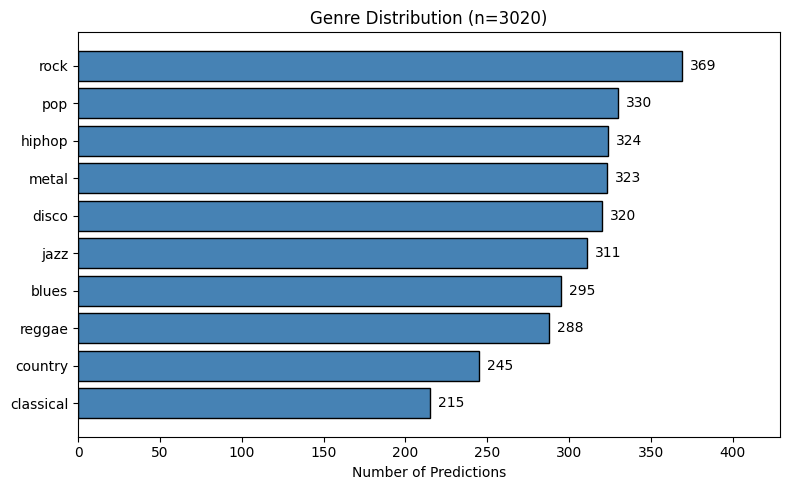

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
lr,█▄▁▁▁▁▁▁▁▁▁▁▁
phase,▁▁▁██████████
train/f1,▁▄▄▅▇▇███████
train/loss,█▅▅▄▃▂▁▁▁▁▁▁▁
val/f1,▁▂▂▂▄▅▇▇▇▆█▆▇
val/loss,███▅▄▄▂▁▁▂▁▂▂
epoch,13
lr,0
phase,2
train/f1,0.99503


In [23]:
genre_counts = submission['genre'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(genre_counts.index, genre_counts.values, color='steelblue', edgecolor='black')

# value labels on each bar
for bar, val in zip(bars, genre_counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10)

ax.set_xlabel('Number of Predictions')
ax.set_title(f'Genre Distribution (n={len(submission)})')
ax.set_xlim(0, genre_counts.max() + 60)
plt.tight_layout()
plt.savefig('/kaggle/working/genre_distribution.png', dpi=150)
plt.show()

wandb_save('/kaggle/working/genre_distribution.png')
wandb_finish()

In [24]:
from IPython.display import FileLink
FileLink('submission.csv')

/kaggle/working/submission.csv